In [1]:
import os

# 1. Daftarkan token Kaggle milikmu ke sistem Colab
# (Saya sudah memasukkan token dari screenshot-mu ke sini)
os.environ['KAGGLE_API_TOKEN'] = "KGAT_1cd1ff4020f5f2e996f7b7a3ea59fb7f"

# 2. Download dataset Fingers langsung dari server Kaggle
!kaggle datasets download -d koryakinp/fingers

# 3. Ekstrak (unzip) file yang sudah didownload ke folder 'dataset_jari'
!unzip -q -o fingers.zip -d dataset_jari

print("Dataset berhasil didownload dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/koryakinp/fingers
License(s): CC0-1.0
100% 363M/363M [00:10<00:00, 35.1MB/s]

Dataset berhasil didownload dan diekstrak!


In [2]:
import os
import shutil

# Path asal dataset dari Kaggle
base_dir = '/content/dataset_jari/fingers'
train_dir_asal = os.path.join(base_dir, 'train')
test_dir_asal = os.path.join(base_dir, 'test')

# Path tujuan untuk dataset yang sudah dirapikan
train_dir_rapi = '/content/dataset_rapi/train'
test_dir_rapi = '/content/dataset_rapi/test'

def rapikan_dataset(asal, tujuan):
    # Buat folder 0 sampai 5
    for i in range(6):
        os.makedirs(os.path.join(tujuan, str(i)), exist_ok=True)

    # Pindahkan file berdasarkan angka di nama filenya
    for nama_file in os.listdir(asal):
        if nama_file.endswith(".png"):
            # Format nama file dari kaggle: "xxxx_5L.png". Kita ambil angka ke-2 dari belakang (yaitu '5')
            label = nama_file.split('.png')[0][-2]

            path_asal = os.path.join(asal, nama_file)
            path_tujuan = os.path.join(tujuan, label, nama_file)
            shutil.copy(path_asal, path_tujuan)

print("Sedang menyortir dan merapikan data Train...")
rapikan_dataset(train_dir_asal, train_dir_rapi)

print("Sedang menyortir dan merapikan data Test...")
rapikan_dataset(test_dir_asal, test_dir_rapi)

print("Selesai! Dataset sudah terbagi sempurna ke dalam folder 0-5.")

Sedang menyortir dan merapikan data Train...
Sedang menyortir dan merapikan data Test...
Selesai! Dataset sudah terbagi sempurna ke dalam folder 0-5.


In [3]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

print("--- Memuat Data Training ---")
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/dataset_rapi/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Memuat Data Validasi ---")
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    '/content/dataset_rapi/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"\nNama kelas yang terdeteksi: {class_names}")

# Normalisasi piksel gambar (dari 0-255 menjadi 0-1 agar AI cepat belajar)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

print("\nData loading dan preprocessing selesai!")

--- Memuat Data Training ---
Found 18000 files belonging to 6 classes.

--- Memuat Data Validasi ---
Found 3600 files belonging to 6 classes.

Nama kelas yang terdeteksi: ['0', '1', '2', '3', '4', '5']

Data loading dan preprocessing selesai!


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. Membangun Arsitektur Model CNN
model = Sequential([
    # Layer Ekstraksi Fitur
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)), # <-- Koma sudah ditambahkan di sini
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Layer Klasifikasi
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout mencegah model "menghafal" buta (overfitting)
    Dense(6, activation='softmax') # 6 kelas karena kita menebak angka 0 sampai 5
])

# 2. Menyiapkan Callbacks (Asisten Pintar)
callbacks = [
    # Berhenti otomatis jika akurasi validasi tidak naik selama 5 putaran (epochs)
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    # Turunkan kecepatan belajar (learning rate) jika model mulai kesulitan
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7),
    # Langsung simpan model terbaik ke dalam file .h5
    ModelCheckpoint('model_jari.h5', monitor='val_accuracy', save_best_only=True)
]

# 3. Kompilasi Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Arsitektur model dan Callbacks berhasil dibuat!")
model.summary()

Arsitektur model dan Callbacks berhasil dibuat!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Memulai proses training AI... (Ini mungkin memakan waktu beberapa menit)
Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8900 - loss: 0.3061

563/563 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.9676 - loss: 0.0955 - val_accuracy: 0.9978 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/10
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9966 - loss: 0.0119

563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.9997 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/10
562/563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9984 - loss: 0.0051

563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 1.0000 - val_loss: 6.9490e-05 - learning_rate: 0.0010
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9978 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 1.9823e-04 - learning_rate: 0.0010
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9987 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 2.2691e-06 - learning_rate: 0.0010
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9993 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 2.5829e-05 - learning_rate: 0.0010
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 4.1406e-07 - learning_rate: 2.0000e-04
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9998 - loss: 5.4484e-04 - val_accuracy: 1.0000 - val_loss: 1.8589e-07 - learning_rate: 2.0000e-04

Training Selesai! Model terbaik otomatis tersimpan

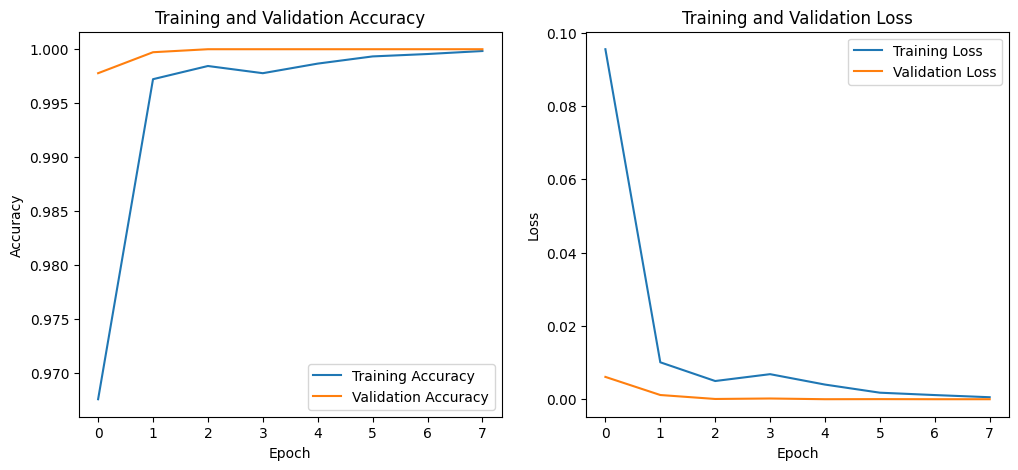


--- Evaluasi Akhir ---
563/563 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 2.0193e-05
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 6.9490e-05
Training Accuracy : 1.0000
Validation Accuracy : 1.0000


In [11]:
import matplotlib.pyplot as plt

print("Memulai proses training AI... (Ini mungkin memakan waktu beberapa menit)")

# 1. Mulai melatih model (kita atur maksimal 10 putaran/epochs)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

print("\nTraining Selesai! Model terbaik otomatis tersimpan sebagai 'model_jari.h5'")

# 2. Visualisasi Grafik Performa (Accuracy dan Loss)
plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Error (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# 3. Evaluasi Akhir
print("\n--- Evaluasi Akhir ---")
train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")